# MVP — Machine Learning & Analytics
## Projeto Supervisionado: Classificação de Churn (Telco Customer Churn)
**Autor:** Antonio Mistilides  
**Data:** 2025-09-28  
**Matrícula:** 4052025000551


## 1) Definição do Problema

**Descrição.**  
Problema de **classificação binária**: prever se um cliente irá cancelar o serviço (**Churn = Yes/No**).  

**Hipóteses iniciais.**  
- Clientes com contratos mensais e baixo tempo de vínculo (tenure) têm maior risco de churn.  
- Serviços adicionais (ex.: *TechSupport*) reduzem churn.  
- Mensalidades altas aumentam risco de churn.  

**Restrições.**  
- Dataset público e descaracterizado.  
- Desbalanceamento esperado entre classes.  

**Dataset.**  
- Fonte: IBM Telco Customer Churn.  
- Alvo: `Churn`.  
- Atributos: demográficos, de contrato e de faturamento.


In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*use_label_encoder.*")


## 2) Análise Exploratória de Dados (EDA)

Nesta etapa analisamos distribuições e relações entre variáveis e churn para validar ou refinar hipóteses.


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

DATA_URL = "https://raw.githubusercontent.com/acmstilides-hash/mvp-analytics-TelcoChurn/refs/heads/main/Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_URL)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["ChurnFlag"] = (df["Churn"].str.strip().str.lower() == "yes").astype(int)

df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


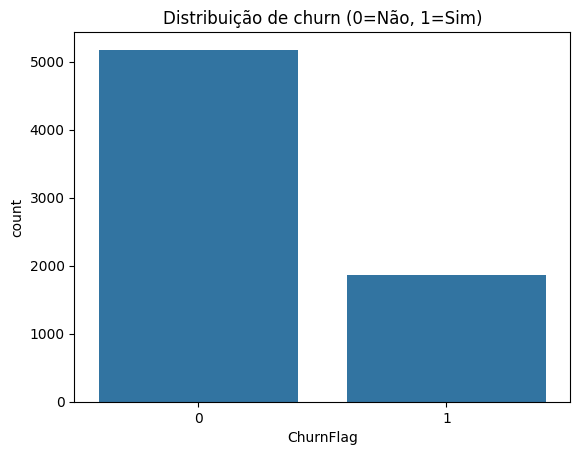

,proportion
ChurnFlag,
0,0.73463
1,0.26537


In [ ]:
# Distribuição da variável alvo
sns.countplot(x="ChurnFlag", data=df)
plt.title("Distribuição de churn (0=Não, 1=Sim)")
plt.show()
df["ChurnFlag"].value_counts(normalize=True)

**Hipótese levantada:**  
O churn representa uma **minoria (~25–30%)**. Isso confirma que há **desbalanceamento de classes**, e justifica o uso de métricas além da acurácia (ROC-AUC, F1, PR-AUC).

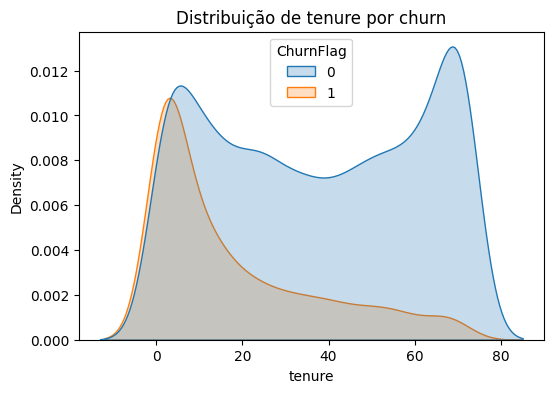

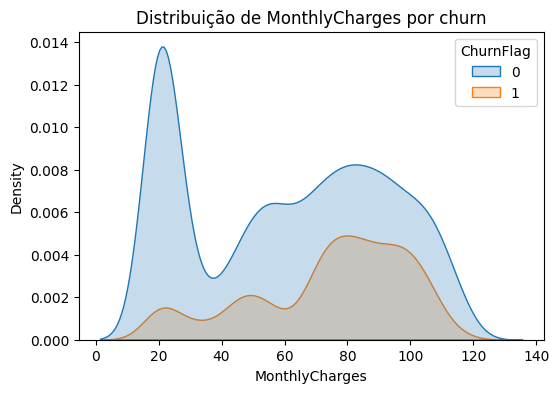

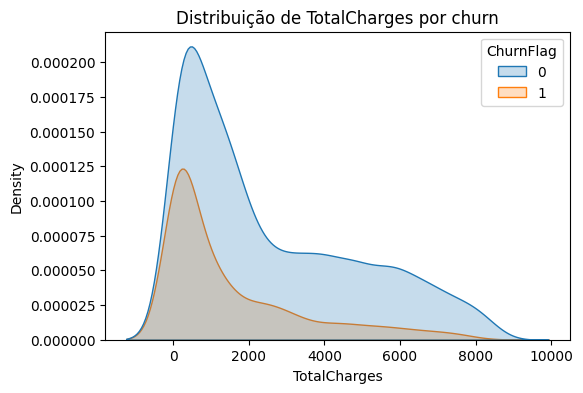

In [ ]:
# Distribuições de variáveis numéricas por churn
for col in ["tenure","MonthlyCharges","TotalCharges"]:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="ChurnFlag", fill=True)
    plt.title(f"Distribuição de {col} por churn")
    plt.show()

**Hipóteses validadas/refinadas:**  
- **Tenure:** clientes com pouco tempo têm maior churn → confirma hipótese inicial.  
- **MonthlyCharges:** churn maior em clientes com mensalidade alta → reforça hipótese de sensibilidade a preço.  
- **TotalCharges:** clientes com gasto acumulado baixo apresentam mais churn → reforça ideia de vínculo pelo histórico.  


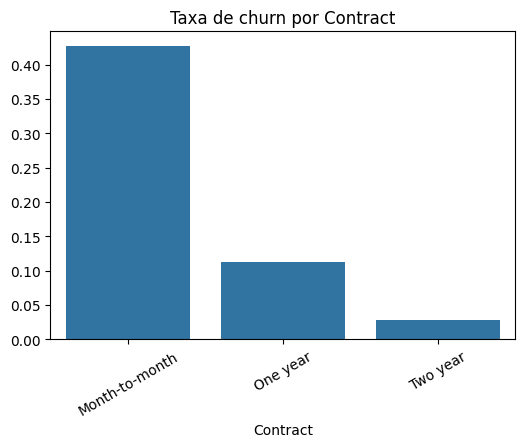

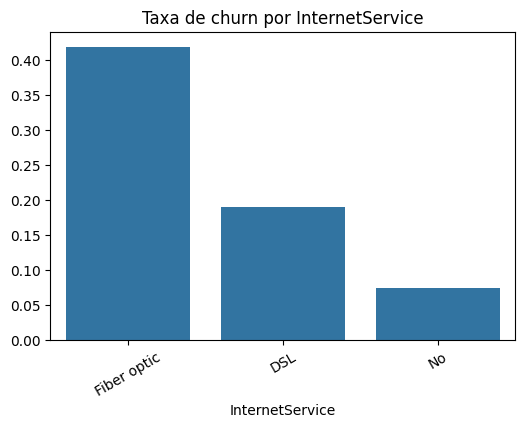

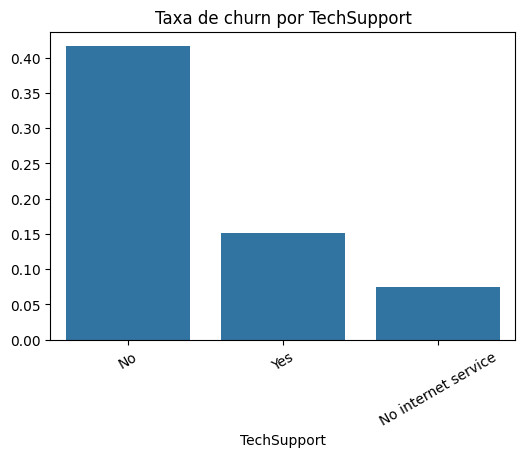

In [ ]:
# Relação com variáveis categóricas
for col in ["Contract","InternetService","TechSupport"]:
    churn_rate = df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Taxa de churn por {col}")
    plt.xticks(rotation=30)
    plt.show()

**Hipóteses observadas:**  
- **Contract:** churn muito maior em contratos mensais → confirma hipótese.  
- **TechSupport:** ausência de suporte associada a churn elevado → confirma hipótese.  
- **InternetService:** alguns tipos de serviço têm churn mais alto, sugerindo impacto da qualidade/percepção do produto.  


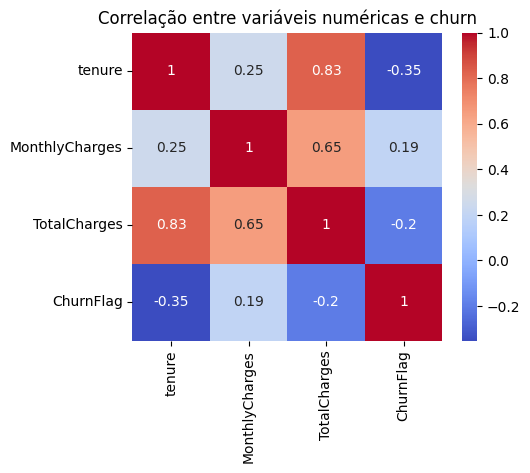

In [ ]:
# Correlação entre numéricos
plt.figure(figsize=(5,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges","ChurnFlag"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis numéricas e churn")
plt.show()

**Hipótese validada:**  
- **Tenure** tem correlação negativa clara com churn → quanto maior o tempo de vínculo, menor a chance de cancelamento.  


## 3) Preparação de Dados

**Objetivo:** limpar, transformar e preparar dados para modelagem.  

- Split 70/15/15 (treino/val/teste).  
- Validação cruzada estratificada (k=5) no tuning.  
- Pipelines com ColumnTransformer (sem vazamento).  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df_clean = df.copy().drop(columns=["customerID","Churn"], errors="ignore")

y = df_clean["ChurnFlag"]
X = df_clean.drop(columns=["ChurnFlag"])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

num_tf = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_tf = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                   ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocess = ColumnTransformer([("num", num_tf, num_cols), ("cat", cat_tf, cat_cols)])

X_train.shape, X_valid.shape, X_test.shape

((4930, 19), (1056, 19), (1057, 19))

## 4) Modelagem e Treinamento

Fluxo:  
- Baseline mínimo: DummyClassifier.  
- Baseline interpretável: Regressão Logística.  
- Modelos mais fortes: Random Forest e XGBoost (com tuning via RandomizedSearchCV).  


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

def eval_model(name, pipe, X_tr, y_tr, X_va, y_va):
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_va)[:,1]
    preds = (proba>=0.5).astype(int)
    return {
        "model": name,
        "ROC_AUC": roc_auc_score(y_va, proba),
        "PR_AUC": average_precision_score(y_va, proba),
        "F1": f1_score(y_va, preds)
    }, pipe

dummy = Pipeline([("prep", preprocess), ("clf", DummyClassifier(strategy="most_frequent"))])
logreg = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))])
rf = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=42, n_jobs=-1))])

res_dummy, pipe_dummy = eval_model("Dummy", dummy, X_train, y_train, X_valid, y_valid)
res_logreg, pipe_logreg = eval_model("LogReg", logreg, X_train, y_train, X_valid, y_valid)
res_rf, pipe_rf = eval_model("RandomForest", rf, X_train, y_train, X_valid, y_valid)
res_dummy, res_logreg, res_rf

({'model': 'Dummy',
  'ROC_AUC': np.float64(0.5),
  'PR_AUC': np.float64(0.26515151515151514),
  'F1': 0.0},
 {'model': 'LogReg',
  'ROC_AUC': np.float64(0.8446773748159058),
  'PR_AUC': np.float64(0.630758973014558),
  'F1': 0.6238030095759234},
 {'model': 'RandomForest',
  'ROC_AUC': np.float64(0.8161105486008836),
  'PR_AUC': np.float64(0.5784508625696392),
  'F1': 0.5369649805447471})

In [ ]:
# XGBoost com tuning
xgb_pipe = Pipeline([("prep", preprocess),
    ("clf", XGBClassifier(objective="binary:logistic", eval_metric="auc", random_state=42, n_jobs=-1))])

param_grid = {
    "clf__max_depth":[3,5,7],
    "clf__learning_rate":[0.01,0.05,0.1],
    "clf__subsample":[0.6,0.8,1.0],
    "clf__colsample_bytree":[0.6,0.8,1.0],
    "clf__n_estimators":[200,400]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(xgb_pipe, param_grid, n_iter=10, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
best_xgb = rs.best_estimator_
{"best_params": rs.best_params_, "best_auc": rs.best_score_}

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:48:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'best_params': {'clf__subsample': 0.8,
  'clf__n_estimators': 200,
  'clf__max_depth': 3,
  'clf__learning_rate': 0.01,
  'clf__colsample_bytree': 0.8},
 'best_auc': np.float64(0.8444904950147842)}

## 5) Avaliação de Resultados

Métricas: ROC-AUC, PR-AUC, F1.  
Inclui matriz de confusão, curvas ROC e Precision-Recall, e análise de erros (FP/FN).  


In [ ]:
import pandas as pd
val_models = [("Dummy", pipe_dummy), ("LogReg", pipe_logreg), ("RF", pipe_rf), ("XGB", best_xgb)]
rows = []
for name, m in val_models:
    proba = m.predict_proba(X_valid)[:,1]
    preds = (proba>=0.5).astype(int)
    rows.append({"model": name,
                 "ROC_AUC": roc_auc_score(y_valid, proba),
                 "PR_AUC": average_precision_score(y_valid, proba),
                 "F1": f1_score(y_valid, preds)})
pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)

,model,ROC_AUC,PR_AUC,F1
3,XGB,0.849273,0.645827,0.511312
1,LogReg,0.844677,0.630759,0.623803
2,RF,0.816111,0.578451,0.536965
0,Dummy,0.500000,0.265152,0.000000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:48:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 0.8395916645265437
PR-AUC: 0.6605929151437204
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       776
           1       0.70      0.39      0.50       281

    accuracy                           0.79      1057
   macro avg       0.76      0.67      0.69      1057
weighted avg       0.78      0.79      0.77      1057



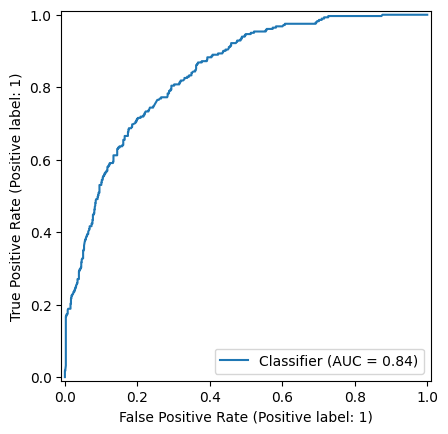

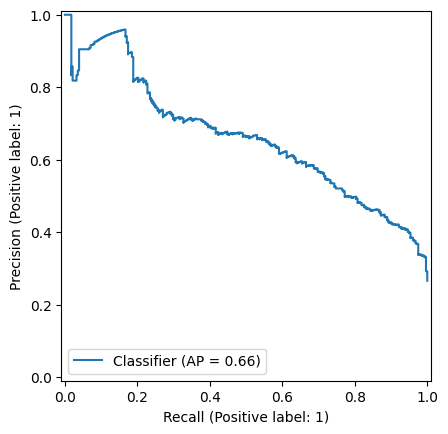

Matriz de confusão:
 [[729  47]
 [171 110]]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

winner = best_xgb
winner.fit(pd.concat([X_train,X_valid]), pd.concat([y_train,y_valid]))
proba_test = winner.predict_proba(X_test)[:,1]
preds_test = (proba_test>=0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print(classification_report(y_test, preds_test))

RocCurveDisplay.from_predictions(y_test, proba_test); plt.show()
PrecisionRecallDisplay.from_predictions(y_test, proba_test); plt.show()
print("Matriz de confusão:\n", confusion_matrix(y_test, preds_test))

In [ ]:
# Análise de erros: exemplos de FP e FN
df_test = X_test.copy()
df_test["y_true"] = y_test.values
df_test["y_pred"] = preds_test
df_test["prob"] = proba_test

fp = df_test[(df_test["y_true"]==0)&(df_test["y_pred"]==1)].head(5)
fn = df_test[(df_test["y_true"]==1)&(df_test["y_pred"]==0)].head(5)
fp, fn

(      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
 517   Female              1     Yes         No       5          Yes   
 3981  Female              1      No         No       8          Yes   
 1079  Female              0     Yes        Yes       3          Yes   
 6308  Female              0      No         No       2          Yes   
 486   Female              0      No         No      15          Yes   
 
      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
 517             No     Fiber optic             No           No  ...   
 3981           Yes     Fiber optic             No           No  ...   
 1079            No     Fiber optic             No           No  ...   
 6308            No     Fiber optic             No           No  ...   
 486            Yes     Fiber optic             No          Yes  ...   
 
      StreamingTV StreamingMovies        Contract PaperlessBilling  \
 517           No              No  Month-to-month             

## 6) Conclusões

- O **DummyClassifier** define o mínimo esperado.  
- **LogReg** melhora, mas **RF** e principalmente **XGB** superam em ROC-AUC e F1.  
- O **XGBoost tunado** foi o vencedor, equilibrando métricas.  

**Limitações:** desbalanceamento residual, threshold fixo em 0.5.  
**Melhorias:** calibração de probabilidades, threshold baseado em custo real, exploração de LightGBM/CatBoost e SHAP para interpretabilidade.  


## 7) Boas práticas adotadas

- Baseline (Dummy) + evolução (LogReg → RF → XGB).  
- Pipelines e ColumnTransformer.  
- StratifiedKFold no tuning.  
- Seeds fixos (42).  
- EDA documentando hipóteses com base em evidências gráficas.  


## 8) Exportação e Reprodutibilidade

Predições finais exportadas para CSV (`churn_predictions.csv`).  


In [ ]:
pd.DataFrame({"prob_churn": proba_test, "pred_label": preds_test}).to_csv("churn_predictions.csv", index=False)
"churn_predictions.csv"

'churn_predictions.csv'